In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
data = pd.read_csv("student.csv")

data.head()


,student_id,study_hours_per_day,attendance_pct,assignments_completed_pct,previous_semester_marks,class_participation,final_score,grade
0,1,4.7,72.4,68,77.6,6,59.0,C
1,2,5.7,71.0,66,67.1,6,67.8,C
2,3,6.3,76.7,55,46.7,6,63.6,C
3,4,5.1,73.4,81,38.8,5,59.7,C
4,5,6.7,71.4,78,69.5,8,65.6,C


In [17]:
print("Dataset Shape:", data.shape)

data.info()

data.describe()

Dataset Shape: (600, 8)
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 600 non-null    int64  
 1   study_hours_per_day        600 non-null    float64
 2   attendance_pct             600 non-null    float64
 3   assignments_completed_pct  600 non-null    int64  
 4   previous_semester_marks    600 non-null    float64
 5   class_participation        600 non-null    int64  
 6   final_score                600 non-null    float64
 7   grade                      600 non-null    str    
dtypes: float64(4), int64(3), str(1)
memory usage: 38.2 KB


,student_id,study_hours_per_day,attendance_pct,assignments_completed_pct,previous_semester_marks,class_participation,final_score
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,300.500000,5.050333,74.792667,68.810000,64.621000,5.933333,63.012833
std,173.349358,1.945973,14.002236,18.815435,18.007191,1.968590,8.982263
min,1.000000,0.000000,37.600000,10.000000,20.000000,1.000000,32.800000
25%,150.750000,3.800000,64.975000,55.000000,51.675000,5.000000,57.200000
50%,300.500000,5.000000,74.750000,68.500000,65.150000,6.000000,63.200000
75%,450.250000,6.300000,85.100000,83.000000,77.900000,7.000000,69.400000
max,600.000000,10.500000,100.000000,100.000000,100.000000,10.000000,92.700000


In [18]:
print("Missing Values Before Handling:")
print(data.isnull().sum())

Missing Values Before Handling:
student_id                   0
study_hours_per_day          0
attendance_pct               0
assignments_completed_pct    0
previous_semester_marks      0
class_participation          0
final_score                  0
grade                        0
dtype: int64


In [19]:

print("Duplicates Before:", data.duplicated().sum())

data.drop_duplicates(inplace=True)

print("Duplicates After:", data.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [20]:
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    data[col].fillna(data[col].mean(), inplace=True)


# Categorical columns -> Fill with Mode
categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    data[col].fillna(data[col].mode()[0], inplace=True)


print("Missing Values After Handling:")
print(data.isnull().sum())

Missing Values After Handling:
student_id                   0
study_hours_per_day          0
attendance_pct               0
assignments_completed_pct    0
previous_semester_marks      0
class_participation          0
final_score                  0
grade                        0
dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_11172\3646395176.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data[col].fillna(data[col].mean(), inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11172\3646395176.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype

In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = data.select_dtypes(include=['object']).columns

for col in categorical_columns:
    encoder = LabelEncoder()

    # Remove extra spaces and convert to string
    data[col] = data[col].astype(str).str.strip()

    data[col] = encoder.fit_transform(data[col])

    label_encoders[col] = encoder


print("Categorical Encoding Completed!")
print(data.dtypes)

Categorical Encoding Completed!
student_id                     int64
study_hours_per_day          float64
attendance_pct               float64
assignments_completed_pct      int64
previous_semester_marks      float64
class_participation            int64
final_score                  float64
grade                          int64
dtype: object


C:\Users\Admin\AppData\Local\Temp\ipykernel_11172\1056819592.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(include=['object']).columns


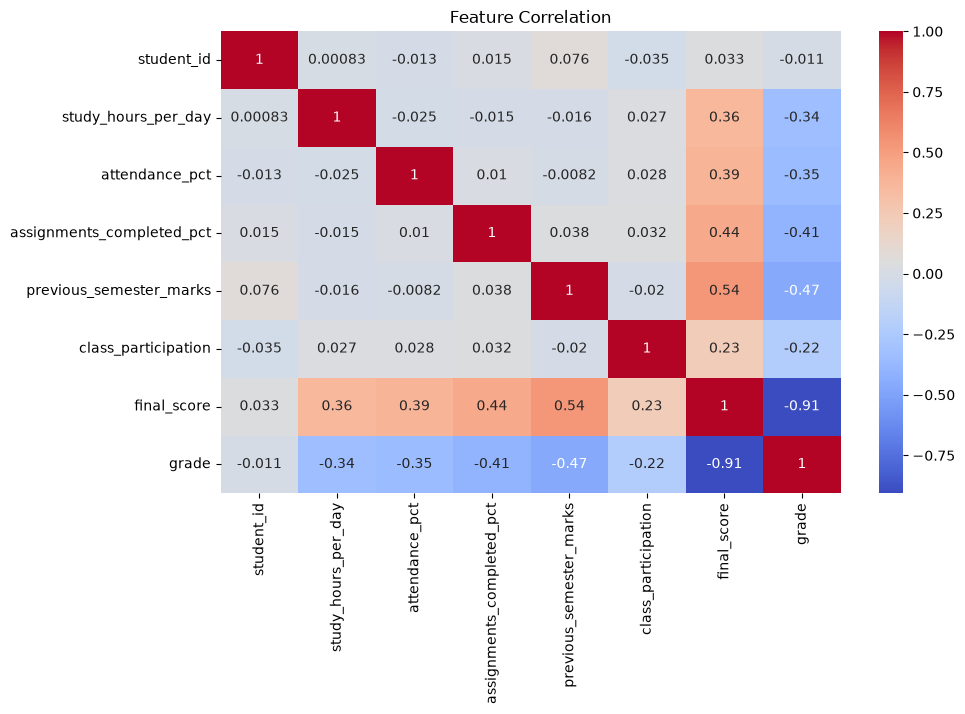

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

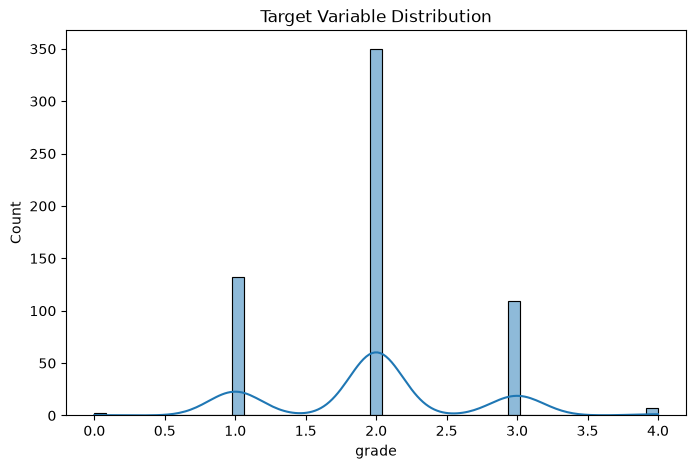

In [23]:
target = data.columns[-1]

plt.figure(figsize=(8,5))

sns.histplot(
    data[target],
    kde=True
)

plt.title("Target Variable Distribution")

plt.show()

In [24]:
X = data.drop(columns=[target])

y = data[target]

print("Features:")
print(X.columns)

Features:
Index(['student_id', 'study_hours_per_day', 'attendance_pct',
       'assignments_completed_pct', 'previous_semester_marks',
       'class_participation', 'final_score'],
      dtype='str')


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_prediction = linear_model.predict(X_test)

In [27]:
linear_accuracy = linear_model.score(
    X_test,
    y_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_prediction
)

linear_mse = mean_squared_error(
    y_test,
    linear_prediction
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)


print("Linear Regression Results")

print("Accuracy:", linear_accuracy)

print("MAE:", linear_mae)

print("MSE:", linear_mse)

print("R2 Score:", linear_r2)

Linear Regression Results
Accuracy: 0.809517411873649
MAE: 0.24346811053103792
MSE: 0.08233080753461171
R2 Score: 0.809517411873649


In [28]:
tree_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

tree_model.fit(
    X_train,
    y_train
)

tree_prediction = tree_model.predict(
    X_test
)

In [29]:
tree_accuracy = tree_model.score(
    X_test,
    y_test
)

tree_mae = mean_absolute_error(
    y_test,
    tree_prediction
)

tree_mse = mean_squared_error(
    y_test,
    tree_prediction
)

tree_r2 = r2_score(
    y_test,
    tree_prediction
)


print("Decision Tree Results")

print("Accuracy:", tree_accuracy)

print("MAE:", tree_mae)

print("MSE:", tree_mse)

print("R2 Score:", tree_r2)

Decision Tree Results
Accuracy: 0.9421593830334191
MAE: 0.025
MSE: 0.025
R2 Score: 0.9421593830334191


In [30]:
results = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Decision Tree"
        ],

        "Accuracy": [
            linear_accuracy,
            tree_accuracy
        ],

        "MAE": [
            linear_mae,
            tree_mae
        ],

        "MSE": [
            linear_mse,
            tree_mse
        ],

        "R2 Score": [
            linear_r2,
            tree_r2
        ]
    }
)


results

,Model,Accuracy,MAE,MSE,R2 Score
0,Linear Regression,0.809517,0.243468,0.082331,0.809517
1,Decision Tree,0.942159,0.025000,0.025000,0.942159


In [31]:
best_model = results.loc[
    results["R2 Score"].idxmax()
]


print("Best Performing Model")
print("----------------------")

print("Model Name:", best_model["Model"])

print("R2 Score:", best_model["R2 Score"])

Best Performing Model
----------------------
Model Name: Decision Tree
R2 Score: 0.9421593830334191
